# Law of Sines — An Intuitive Proof

For any triangle with sides $a$, $b$, $c$ opposite angles $A$, $B$, $C$:

$$\frac{\sin A}{a} = \frac{\sin B}{b} = \frac{\sin C}{c}$$

The idea is beautifully simple: **drop an altitude and watch two right triangles reveal the same hidden ratio.**

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.patches import Arc, FancyArrowPatch

## Step 1 — Drop the Altitude

Take triangle $ABC$ with sides $a$, $b$, $c$ opposite angles $A$, $B$, $C$.

Drop the **altitude** $h$ from vertex $A$ down to side $a$. This splits the big triangle into **two right triangles**:

- **Left right triangle** — has hypotenuse $c$ and angle $B$ at the base.
- **Right right triangle** — has hypotenuse $b$ and angle $C$ at the base.

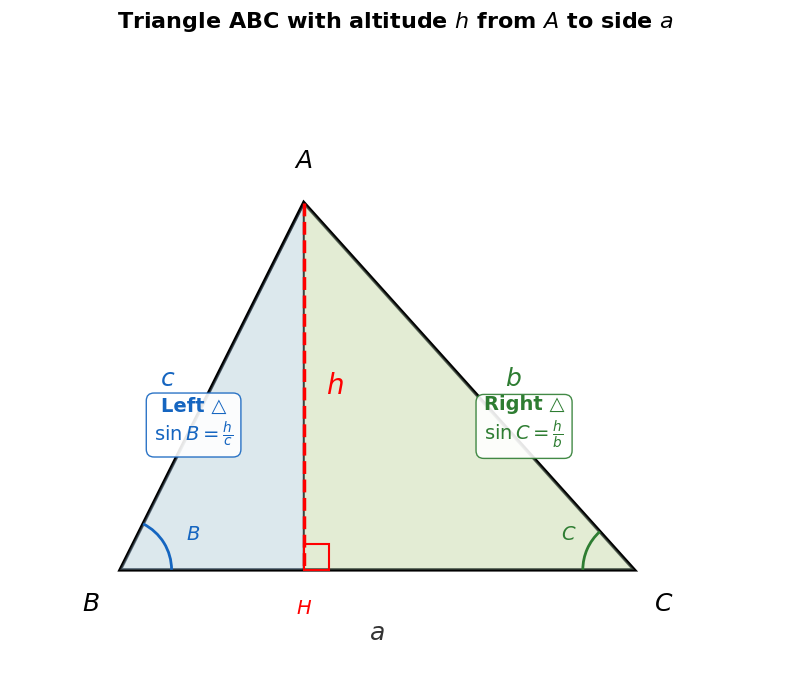

In [2]:
# === DIAGRAM 1: Triangle with altitude showing two right triangles ===

# Use a concrete triangle: B at origin, C to the right, A above
B = np.array([0, 0])
C = np.array([7, 0])
A = np.array([2.5, 5])

# Foot of altitude from A to BC (which lies on x-axis)
H = np.array([A[0], 0])
h_val = A[1]

# Side lengths
a_len = np.linalg.norm(C - B)  # side a = BC
b_len = np.linalg.norm(A - C)  # side b = AC
c_len = np.linalg.norm(A - B)  # side c = AB

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_xlim(-1.5, 9)
ax.set_ylim(-1.5, 7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Triangle ABC with altitude $h$ from $A$ to side $a$',
             fontsize=16, fontweight='bold', pad=20)

# --- Draw the main triangle ---
triangle = plt.Polygon([B, C, A], closed=True,
                        facecolor='#FFF3E0', edgecolor='black', linewidth=2.5)
ax.add_patch(triangle)

# --- Color the two right triangles ---
# Left right triangle (B, H, A) — uses angle B and hypotenuse c
left_tri = plt.Polygon([B, H, A], closed=True,
                        facecolor='#BBDEFB', edgecolor='black', linewidth=1.5, alpha=0.5)
ax.add_patch(left_tri)

# Right right triangle (H, C, A) — uses angle C and hypotenuse b
right_tri = plt.Polygon([H, C, A], closed=True,
                         facecolor='#C8E6C9', edgecolor='black', linewidth=1.5, alpha=0.5)
ax.add_patch(right_tri)

# --- Altitude h (dashed) ---
ax.plot([A[0], H[0]], [A[1], H[1]], 'r--', linewidth=2.5, zorder=5)
ax.text(A[0] + 0.3, h_val / 2, '$h$', fontsize=20, color='red', fontweight='bold', va='center')

# --- Right angle marker at H ---
sq_size = 0.35
sq = plt.Polygon([[H[0], H[1]], [H[0] + sq_size, H[1]],
                   [H[0] + sq_size, H[1] + sq_size], [H[0], H[1] + sq_size]],
                  closed=True, facecolor='none', edgecolor='red', linewidth=1.5)
ax.add_patch(sq)

# --- Label vertices ---
ax.text(A[0], A[1] + 0.4, '$A$', fontsize=18, ha='center', va='bottom', fontweight='bold')
ax.text(B[0] - 0.4, B[1] - 0.3, '$B$', fontsize=18, ha='center', va='top', fontweight='bold')
ax.text(C[0] + 0.4, C[1] - 0.3, '$C$', fontsize=18, ha='center', va='top', fontweight='bold')
ax.text(H[0], H[1] - 0.4, '$H$', fontsize=14, ha='center', va='top', color='red')

# --- Label sides ---
# Side a = BC (bottom)
ax.text((B[0] + C[0]) / 2, -0.7, '$a$', fontsize=18, ha='center', va='top',
        fontweight='bold', color='#333')

# Side c = AB (left)
mid_c = (A + B) / 2
ax.text(mid_c[0] - 0.6, mid_c[1] + 0.1, '$c$', fontsize=18, ha='center', va='center',
        fontweight='bold', color='#1565C0')

# Side b = AC (right)
mid_b = (A + C) / 2
ax.text(mid_b[0] + 0.6, mid_b[1] + 0.1, '$b$', fontsize=18, ha='center', va='center',
        fontweight='bold', color='#2E7D32')

# --- Angle arcs ---
# Angle B
angle_B = np.degrees(np.arctan2(A[1] - B[1], A[0] - B[0]))
arc_B = Arc(B, 1.4, 1.4, angle=0, theta1=0, theta2=angle_B,
            color='#1565C0', linewidth=2)
ax.add_patch(arc_B)
ax.text(B[0] + 0.9, B[1] + 0.4, '$B$', fontsize=14, color='#1565C0', fontweight='bold')

# Angle C
angle_C_start = np.degrees(np.arctan2(A[1] - C[1], A[0] - C[0]))
arc_C = Arc(C, 1.4, 1.4, angle=0, theta1=angle_C_start, theta2=180,
            color='#2E7D32', linewidth=2)
ax.add_patch(arc_C)
ax.text(C[0] - 1.0, C[1] + 0.4, '$C$', fontsize=14, color='#2E7D32', fontweight='bold')

# --- Annotations for the two right triangles ---
ax.text(1.0, 2.0, 'Left △\n$\\sin B = \\frac{h}{c}$', fontsize=14,
        ha='center', va='center', color='#1565C0', fontweight='bold',
        bbox=dict(fc='white', ec='#1565C0', boxstyle='round,pad=0.4', alpha=0.9))

ax.text(5.5, 2.0, 'Right △\n$\\sin C = \\frac{h}{b}$', fontsize=14,
        ha='center', va='center', color='#2E7D32', fontweight='bold',
        bbox=dict(fc='white', ec='#2E7D32', boxstyle='round,pad=0.4', alpha=0.9))

plt.tight_layout()
plt.show()

## Step 2 — Two Expressions for the Same Height

From the **left right triangle** (hypotenuse $c$, angle $B$):

$$\sin B = \frac{h}{c} \quad \Longrightarrow \quad h = c \cdot \sin B$$

From the **right right triangle** (hypotenuse $b$, angle $C$):

$$\sin C = \frac{h}{b} \quad \Longrightarrow \quad h = b \cdot \sin C$$

Both expressions equal the **same** altitude $h$, so:

$$c \cdot \sin B = b \cdot \sin C$$

Divide both sides by $bc$:

$$\frac{\sin B}{b} = \frac{\sin C}{c}$$

Drop a different altitude (from $B$ to side $b$, or from $C$ to side $c$) and the same argument gives:

$$\boxed{\frac{\sin A}{a} = \frac{\sin B}{b} = \frac{\sin C}{c}}$$

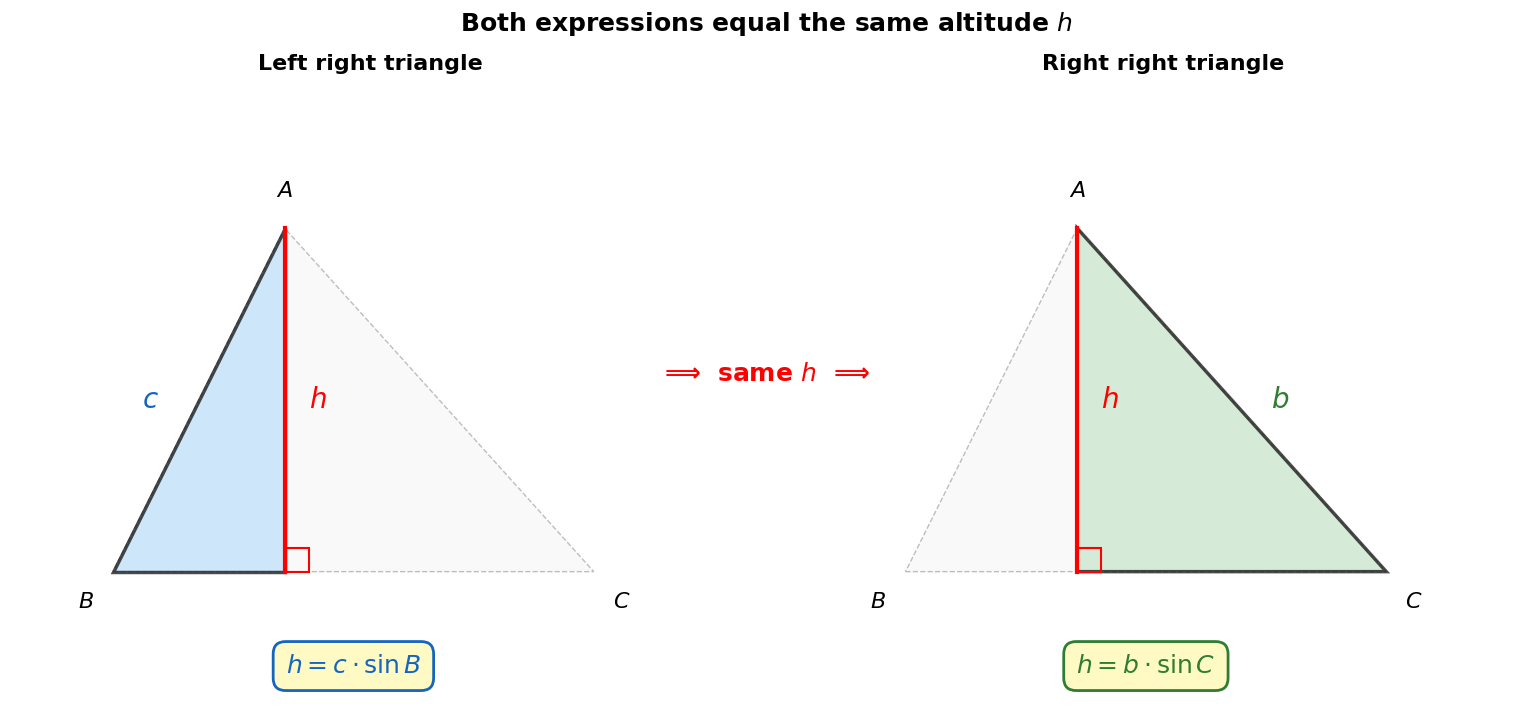

In [3]:
# === DIAGRAM 2: Visual derivation — same h, two expressions ===

B = np.array([0, 0])
C = np.array([7, 0])
A = np.array([2.5, 5])
H = np.array([A[0], 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, title, tri_pts, tri_color, side_label, side_color, angle_label, angle_color, eq_text in [
    (ax1, 'Left right triangle',
     [B, H, A], '#BBDEFB', '$c$', '#1565C0', '$B$', '#1565C0',
     '$h = c \\cdot \\sin B$'),
    (ax2, 'Right right triangle',
     [H, C, A], '#C8E6C9', '$b$', '#2E7D32', '$C$', '#2E7D32',
     '$h = b \\cdot \\sin C$'),
]:
    ax.set_xlim(-1.5, 9)
    ax.set_ylim(-2.0, 7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)

    # Full triangle (faded)
    ax.add_patch(plt.Polygon([B, C, A], closed=True,
                              fc='#F5F5F5', ec='grey', lw=1, ls='--', alpha=0.5))

    # Highlighted right triangle
    ax.add_patch(plt.Polygon(tri_pts, closed=True,
                              fc=tri_color, ec='black', lw=2.5, alpha=0.7))

    # Altitude h
    ax.plot([A[0], H[0]], [A[1], H[1]], 'r-', linewidth=3, zorder=5)
    ax.text(A[0] + 0.35, A[1] / 2, '$h$', fontsize=20, color='red',
            fontweight='bold', va='center')

    # Right angle marker
    sq = 0.35
    ax.add_patch(plt.Polygon([[H[0], H[1]], [H[0]+sq, H[1]],
                               [H[0]+sq, H[1]+sq], [H[0], H[1]+sq]],
                              fc='none', ec='red', lw=1.5))

    # Vertices
    ax.text(A[0], A[1]+0.4, '$A$', fontsize=16, ha='center', va='bottom', fontweight='bold')
    ax.text(B[0]-0.4, B[1]-0.3, '$B$', fontsize=16, ha='center', va='top', fontweight='bold')
    ax.text(C[0]+0.4, C[1]-0.3, '$C$', fontsize=16, ha='center', va='top', fontweight='bold')

    # Equation below
    ax.text(3.5, -1.2, eq_text, fontsize=18, ha='center', va='top',
            fontweight='bold', color=side_color,
            bbox=dict(fc='#FFF9C4', ec=side_color, boxstyle='round,pad=0.5', lw=2))

# Side labels — left panel
mid_c = (A + B) / 2
ax1.text(mid_c[0] - 0.7, mid_c[1], '$c$', fontsize=20, ha='center', va='center',
         fontweight='bold', color='#1565C0')

# Side labels — right panel
mid_b = (A + C) / 2
ax2.text(mid_b[0] + 0.7, mid_b[1], '$b$', fontsize=20, ha='center', va='center',
         fontweight='bold', color='#2E7D32')

# Central equals
fig.text(0.5, 0.5, '⟹  same $h$  ⟹', fontsize=18, ha='center', va='center',
         fontweight='bold', color='red')

plt.suptitle('Both expressions equal the same altitude $h$',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 3 — Normalization: Why Dividing by the Side Cancels Scale

Here's the key intuition:

- $\sin B$ tells you the **height proportion** relative to side $c$.
- $\sin C$ tells you the **height proportion** relative to side $b$.

When you compute $\dfrac{\sin B}{b}$, you're asking:

> *"How much height do I get **per unit** of side $b$?"*

This **strips away the triangle's scale**, leaving a **pure geometric ratio** that depends only on the triangle's *shape*, not its *size*.

That's why all three ratios $\dfrac{\sin A}{a} = \dfrac{\sin B}{b} = \dfrac{\sin C}{c}$ are equal — they're different windows into the **same underlying symmetry**.

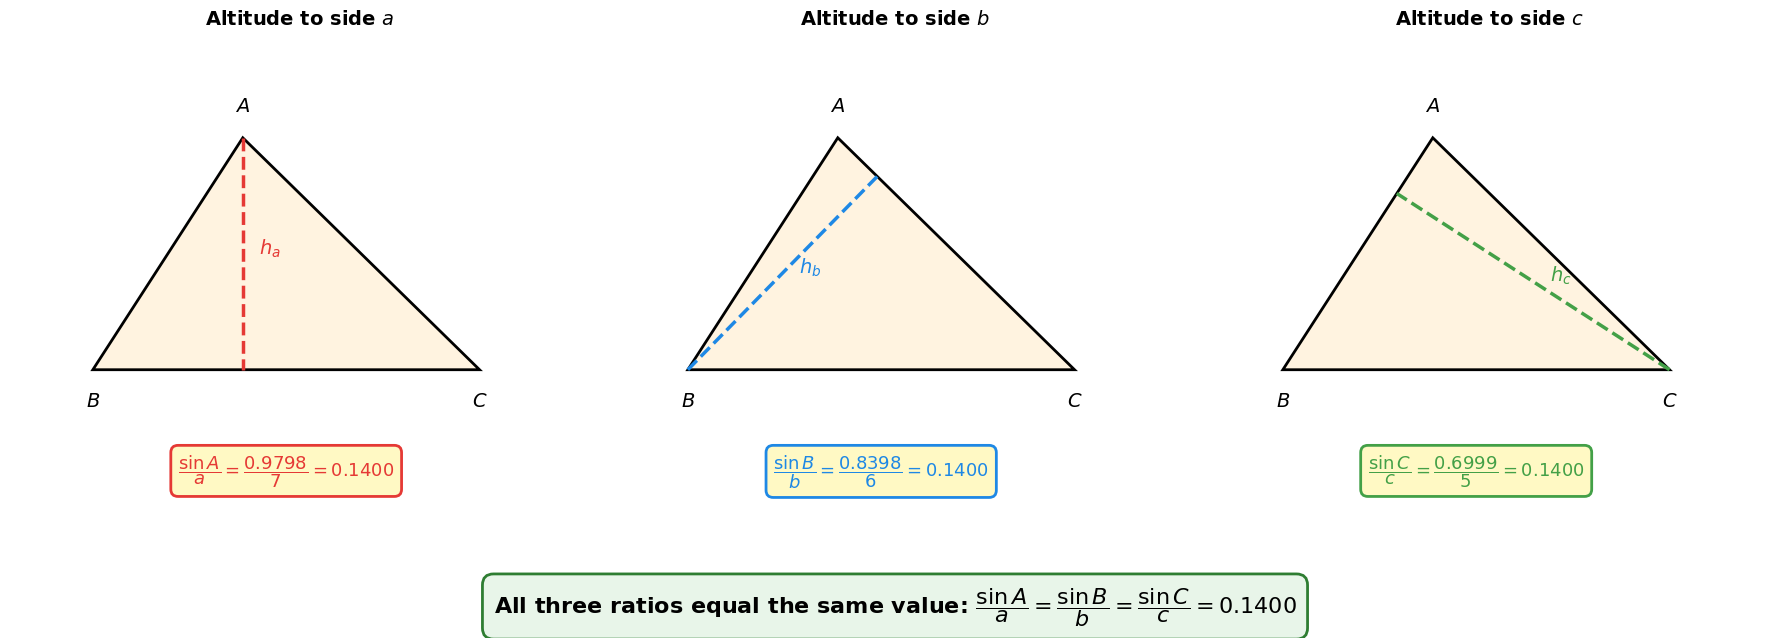

In [4]:
# === DIAGRAM 3: Normalization — three altitudes, one ratio ===

# Triangle with sides 5, 6, 7 (use law of cosines to place vertices)
a_s, b_s, c_s = 7, 6, 5  # sides opposite A, B, C

# Place B at origin, C at (a_s, 0)
Bv = np.array([0.0, 0.0])
Cv = np.array([a_s, 0.0])

# Find A using law of cosines: cos(B) = (a² + c² - b²) / 2ac
cos_B = (a_s**2 + c_s**2 - b_s**2) / (2 * a_s * c_s)
sin_B = np.sqrt(1 - cos_B**2)
Av = np.array([c_s * cos_B, c_s * sin_B])

# Compute all three altitudes and angles
angle_A = np.arccos((b_s**2 + c_s**2 - a_s**2) / (2 * b_s * c_s))
angle_B = np.arccos(cos_B)
angle_C = np.arccos((a_s**2 + b_s**2 - c_s**2) / (2 * a_s * b_s))

h_a = c_s * np.sin(angle_B)  # altitude to side a
h_b = a_s * np.sin(angle_C)  # altitude to side b
h_c = b_s * np.sin(angle_A)  # altitude to side c

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs = [
    ('Altitude to side $a$', Av, Bv, Cv, a_s, h_a, angle_A, 'A', '#E53935'),
    ('Altitude to side $b$', Bv, Av, Cv, b_s, h_b, angle_B, 'B', '#1E88E5'),
    ('Altitude to side $c$', Cv, Av, Bv, c_s, h_c, angle_C, 'C', '#43A047'),
]

for ax, (title, apex, v1, v2, side, h, angle, ang_label, color) in zip(axes, configs):
    ax.set_xlim(-1.5, 9)
    ax.set_ylim(-2.5, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    # Draw full triangle
    ax.add_patch(plt.Polygon([Av, Bv, Cv], closed=True,
                              fc='#FFF3E0', ec='black', lw=2))

    # Compute foot of altitude from apex to opposite side (v1 to v2)
    v1v2 = v2 - v1
    t = np.dot(apex - v1, v1v2) / np.dot(v1v2, v1v2)
    foot = v1 + t * v1v2

    # Draw altitude
    ax.plot([apex[0], foot[0]], [apex[1], foot[1]],
            color=color, linewidth=2.5, linestyle='--', zorder=5)

    # Label h
    mid_h = (apex + foot) / 2
    ax.text(mid_h[0] + 0.3, mid_h[1], f'$h_{ang_label.lower()}$',
            fontsize=14, color=color, fontweight='bold')

    # Label vertices
    for v, lbl in [(Av, 'A'), (Bv, 'B'), (Cv, 'C')]:
        offset = np.array([0, 0.4]) if v[1] > 1 else np.array([0, -0.4])
        va = 'bottom' if v[1] > 1 else 'top'
        ax.text(v[0] + offset[0], v[1] + offset[1], f'${lbl}$',
                fontsize=14, ha='center', va=va, fontweight='bold')

    # Show the ratio below
    ratio_val = np.sin(angle) / side
    ax.text(3.5, -1.5,
            f'$\\dfrac{{\\sin {ang_label}}}{{{ang_label.lower()}}}'
            f' = \\dfrac{{{np.sin(angle):.4f}}}{{{side}}}'
            f' = {ratio_val:.4f}$',
            fontsize=13, ha='center', va='top', color=color, fontweight='bold',
            bbox=dict(fc='#FFF9C4', ec=color, boxstyle='round,pad=0.4', lw=2))

# Grand result
ratio = np.sin(angle_A) / a_s
fig.text(0.5, -0.02,
         f'All three ratios equal the same value: '
         f'$\\dfrac{{\\sin A}}{{a}} = \\dfrac{{\\sin B}}{{b}} = \\dfrac{{\\sin C}}{{c}}'
         f' = {ratio:.4f}$',
         fontsize=16, ha='center', va='top', fontweight='bold',
         bbox=dict(fc='#E8F5E9', ec='#2E7D32', boxstyle='round,pad=0.5', lw=2))

plt.tight_layout()
plt.show()

## Step 4 — Numerical Example: Triangle with sides 5, 6, 7

Let's verify the Law of Sines with a concrete triangle and see the ratios equalize in numbers.

In [5]:
# === Numerical verification: triangle with sides 5, 6, 7 ===

a, b, c = 7, 6, 5  # sides opposite angles A, B, C

# Angles via law of cosines
A_angle = np.arccos((b**2 + c**2 - a**2) / (2 * b * c))
B_angle = np.arccos((a**2 + c**2 - b**2) / (2 * a * c))
C_angle = np.arccos((a**2 + b**2 - c**2) / (2 * a * b))

print("Triangle with sides a=7, b=6, c=5")
print("=" * 45)
print(f"Angle A = {np.degrees(A_angle):.2f}°")
print(f"Angle B = {np.degrees(B_angle):.2f}°")
print(f"Angle C = {np.degrees(C_angle):.2f}°")
print(f"Sum     = {np.degrees(A_angle + B_angle + C_angle):.2f}°  ✓")
print()
print("Law of Sines ratios:")
print("-" * 45)
print(f"sin(A)/a = {np.sin(A_angle):.6f} / {a} = {np.sin(A_angle)/a:.6f}")
print(f"sin(B)/b = {np.sin(B_angle):.6f} / {b} = {np.sin(B_angle)/b:.6f}")
print(f"sin(C)/c = {np.sin(C_angle):.6f} / {c} = {np.sin(C_angle)/c:.6f}")
print()

ratios = [np.sin(A_angle)/a, np.sin(B_angle)/b, np.sin(C_angle)/c]
print(f"All equal? Max difference = {max(ratios) - min(ratios):.2e}  ✓")
print()

# Altitudes
h_a = c * np.sin(B_angle)
h_b = a * np.sin(C_angle)
h_c = b * np.sin(A_angle)
print("Heights (verification):")
print("-" * 45)
print(f"h_a = c·sin(B) = {c}·{np.sin(B_angle):.4f} = {h_a:.4f}")
print(f"h_a = b·sin(C) = {b}·{np.sin(C_angle):.4f} = {b * np.sin(C_angle):.4f}  ← same! ✓")
print()
print(f"h_b = a·sin(C) = {a}·{np.sin(C_angle):.4f} = {h_b:.4f}")
print(f"h_b = c·sin(A) = {c}·{np.sin(A_angle):.4f} = {c * np.sin(A_angle):.4f}  ← same! ✓")
print()
print(f"h_c = b·sin(A) = {b}·{np.sin(A_angle):.4f} = {h_c:.4f}")
print(f"h_c = a·sin(B) = {a}·{np.sin(B_angle):.4f} = {a * np.sin(B_angle):.4f}  ← same! ✓")

Triangle with sides a=7, b=6, c=5
Angle A = 78.46°
Angle B = 57.12°
Angle C = 44.42°
Sum     = 180.00°  ✓

Law of Sines ratios:
---------------------------------------------
sin(A)/a = 0.979796 / 7 = 0.139971
sin(B)/b = 0.839825 / 6 = 0.139971
sin(C)/c = 0.699854 / 5 = 0.139971

All equal? Max difference = 2.78e-17  ✓

Heights (verification):
---------------------------------------------
h_a = c·sin(B) = 5·0.8398 = 4.1991
h_a = b·sin(C) = 6·0.6999 = 4.1991  ← same! ✓

h_b = a·sin(C) = 7·0.6999 = 4.8990
h_b = c·sin(A) = 5·0.9798 = 4.8990  ← same! ✓

h_c = b·sin(A) = 6·0.9798 = 5.8788
h_c = a·sin(B) = 7·0.8398 = 5.8788  ← same! ✓


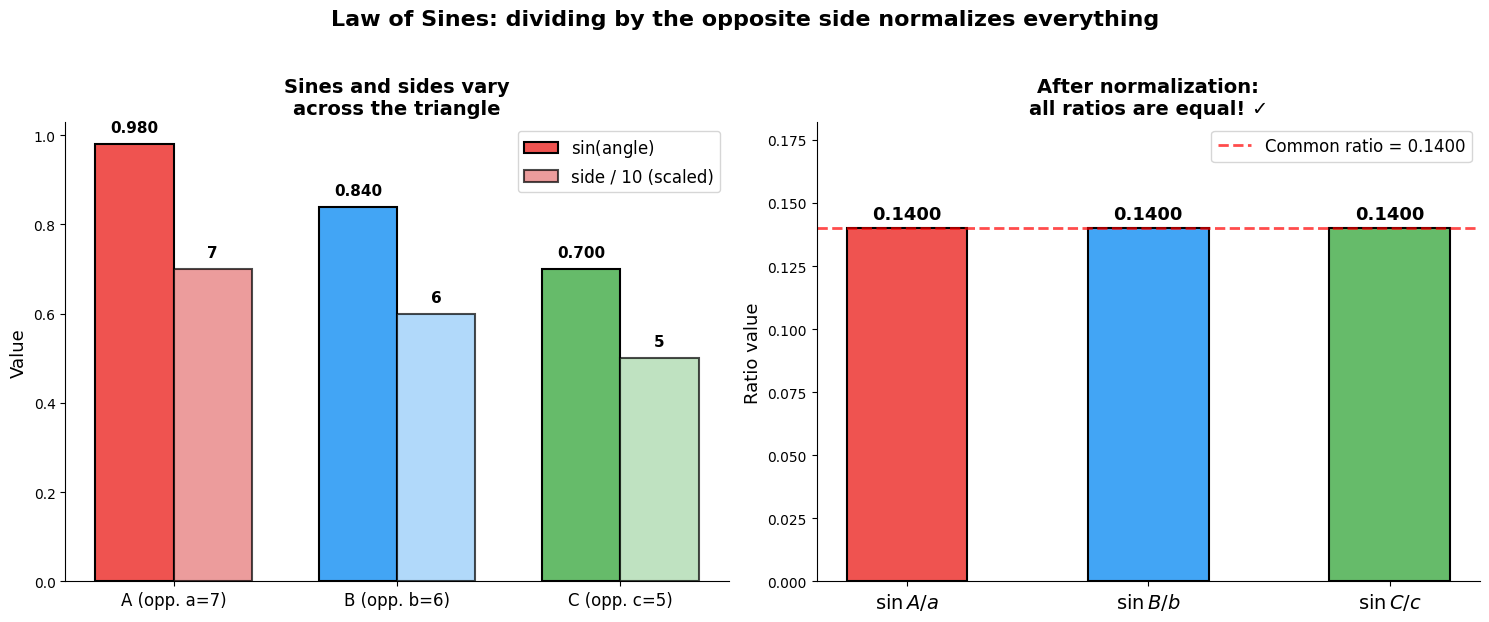

In [6]:
# === DIAGRAM 4: Bar chart — the three ratios are equal ===

a, b, c = 7, 6, 5
A_angle = np.arccos((b**2 + c**2 - a**2) / (2 * b * c))
B_angle = np.arccos((a**2 + c**2 - b**2) / (2 * a * c))
C_angle = np.arccos((a**2 + b**2 - c**2) / (2 * a * b))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: sines and sides separately ---
labels = ['A', 'B', 'C']
sines = [np.sin(A_angle), np.sin(B_angle), np.sin(C_angle)]
sides = [a, b, c]
colors_sin = ['#EF5350', '#42A5F5', '#66BB6A']
colors_side = ['#E57373', '#90CAF9', '#A5D6A7']

x = np.arange(3)
w = 0.35

bars1 = ax1.bar(x - w/2, sines, w, label='$\\sin(\\text{angle})$',
                color=colors_sin, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + w/2, [s / 10 for s in sides], w,
                label='side / 10 (scaled)', color=colors_side,
                edgecolor='black', linewidth=1.5, alpha=0.7)

# Value labels on bars
for bar, val in zip(bars1, sines):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, sides):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(['A (opp. a=7)', 'B (opp. b=6)', 'C (opp. c=5)'], fontsize=12)
ax1.set_title('Sines and sides vary\nacross the triangle', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.set_ylabel('Value', fontsize=13)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right: the normalized ratios are equal ---
ratios = [np.sin(A_angle)/a, np.sin(B_angle)/b, np.sin(C_angle)/c]

bars = ax2.bar(x, ratios, 0.5, color=colors_sin, edgecolor='black', linewidth=1.5)
for bar, val, lbl in zip(bars, ratios, labels):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([f'$\\sin {l} / {l.lower()}$' for l in labels], fontsize=14)
ax2.set_title('After normalization:\nall ratios are equal! ✓', fontsize=14, fontweight='bold')
ax2.set_ylabel('Ratio value', fontsize=13)
ax2.set_ylim(0, max(ratios) * 1.3)

# Draw a horizontal line at the common ratio
ax2.axhline(y=ratios[0], color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Common ratio = {ratios[0]:.4f}')
ax2.legend(fontsize=12, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Law of Sines: dividing by the opposite side normalizes everything',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Summary — The Big Picture

The Law of Sines is a statement of **symmetry**:

1. **Drop an altitude** from any vertex → it creates two right triangles that share the same height $h$.
2. **Two expressions for $h$** → e.g. $h = c \sin B = b \sin C$.
3. **Divide by $bc$** → the triangle's scale cancels, leaving $\dfrac{\sin B}{b} = \dfrac{\sin C}{c}$.
4. **Repeat** for any pair → all three ratios are equal.

### ✨ Intuitive Takeaway

Every triangle has one **hidden scale factor** that ties its sides and angles together. The sine of an angle gives you a *height proportion*, and dividing by the opposite side cancels the triangle's size, leaving a **pure geometric ratio**. That's why all three ratios match — they're different windows into the same underlying symmetry.

$$\boxed{\frac{\sin A}{a} = \frac{\sin B}{b} = \frac{\sin C}{c} = \frac{1}{2R}}$$

where $R$ is the **circumradius** (radius of the circumscribed circle) — but that's a story for another notebook! 🔵